# COVID-19 Data Analysis and Visualization


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("covid19_summary.csv")
df.head()

,Province/State,Country,Date last updated,Confirmed,Suspected,Recovered,Deaths
0,Shanghai,Mainland China,1/21/2020,9.0,10.0,NaN,NaN
1,Yunnan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
2,Beijing,Mainland China,1/21/2020,10.0,NaN,NaN,NaN
3,Taiwan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
4,Jilin,Mainland China,1/21/2020,NaN,1.0,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Province/State     304 non-null    str    
 1   Country            368 non-null    str    
 2   Date last updated  368 non-null    str    
 3   Confirmed          339 non-null    float64
 4   Suspected          88 non-null     float64
 5   Recovered          36 non-null     float64
 6   Deaths             24 non-null     float64
dtypes: float64(4), str(3)
memory usage: 20.3 KB


## 3. Data Cleaning

In [4]:
df['Date last updated'] = pd.to_datetime(df['Date last updated'], format='mixed', errors='coerce')
df['Date'] = df['Date last updated'].dt.date
df[['Confirmed', 'Suspected', 'Recovered', 'Deaths']] = df[['Confirmed', 'Suspected', 'Recovered', 'Deaths']].fillna(0)
df['Country'] = df['Country'].replace({'Mainland China': 'China'})
df.head()

,Province/State,Country,Date last updated,Confirmed,Suspected,Recovered,Deaths,Date
0,Shanghai,China,2020-01-21,9.0,10.0,0.0,0.0,2020-01-21
1,Yunnan,China,2020-01-21,1.0,0.0,0.0,0.0,2020-01-21
2,Beijing,China,2020-01-21,10.0,0.0,0.0,0.0,2020-01-21
3,Taiwan,China,2020-01-21,1.0,0.0,0.0,0.0,2020-01-21
4,Jilin,China,2020-01-21,0.0,1.0,0.0,0.0,2020-01-21


In [5]:
df.isnull().sum()

Province/State       64
Country               0
Date last updated     0
Confirmed             0
Suspected             0
Recovered             0
Deaths                0
Date                  0
dtype: int64

## 4. Global Summary Statistics

In [6]:
latest_date = df['Date'].max()
latest_df = df[df['Date'] == latest_date]

total_confirmed = latest_df['Confirmed'].sum()
total_recovered = latest_df['Recovered'].sum()
total_deaths = latest_df['Deaths'].sum()

print(f"As of {latest_date}")
print(f"Total Confirmed: {int(total_confirmed)}")
print(f"Total Recovered: {int(total_recovered)}")
print(f"Total Deaths: {int(total_deaths)}")

As of 2020-01-26
Total Confirmed: 2116
Total Recovered: 52
Total Deaths: 56


## 5. Trends Over Time

In [7]:
trend = df.groupby('Date')[['Confirmed', 'Recovered', 'Deaths']].sum().reset_index()
trend

,Date,Confirmed,Recovered,Deaths
0,2020-01-21,332.0,0.0,0.0
1,2020-01-22,555.0,0.0,0.0
2,2020-01-23,653.0,30.0,18.0
3,2020-01-24,1822.0,70.0,52.0
4,2020-01-25,4811.0,126.0,139.0
5,2020-01-26,2116.0,52.0,56.0


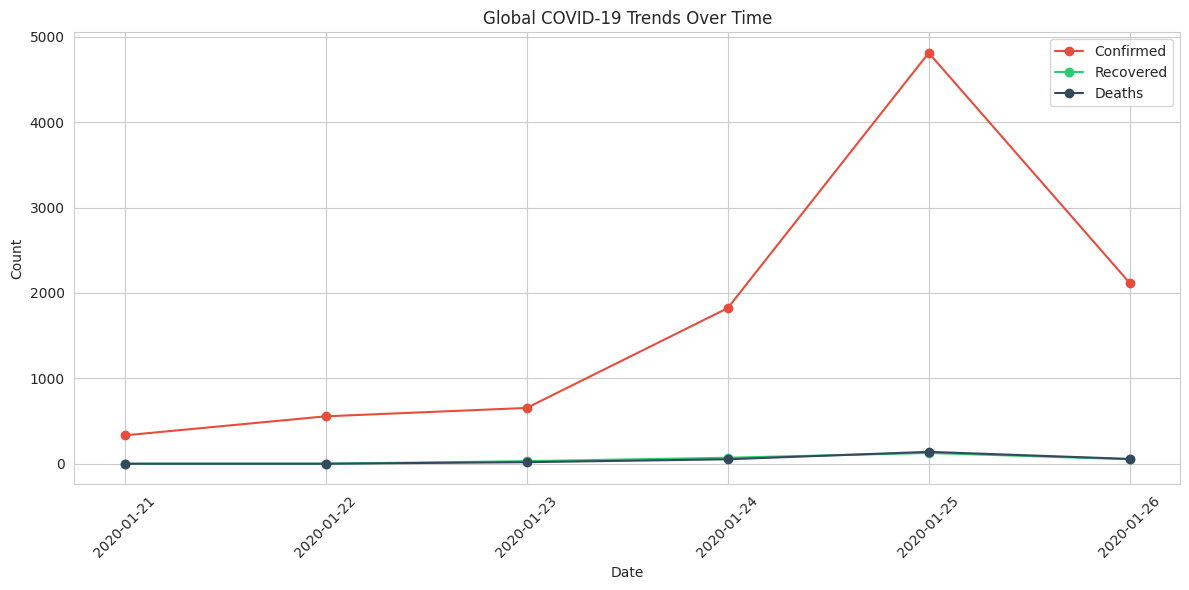

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(trend['Date'], trend['Confirmed'], marker='o', label='Confirmed', color='#e74c3c')
ax.plot(trend['Date'], trend['Recovered'], marker='o', label='Recovered', color='#2ecc71')
ax.plot(trend['Date'], trend['Deaths'], marker='o', label='Deaths', color='#34495e')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
ax.set_title('Global COVID-19 Trends Over Time')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Confirmed Cases by Country

In [9]:
country_totals = latest_df.groupby('Country')[['Confirmed', 'Recovered', 'Deaths']].sum().sort_values('Confirmed', ascending=False)
country_totals

,Confirmed,Recovered,Deaths
Country,,,
China,2062.0,49.0,56.0
Hong Kong,8.0,0.0,0.0
Thailand,8.0,2.0,0.0
Macau,5.0,0.0,0.0
Japan,4.0,1.0,0.0
Malaysia,4.0,0.0,0.0
Australia,4.0,0.0,0.0
Taiwan,4.0,0.0,0.0
Singapore,4.0,0.0,0.0


/tmp/ipykernel_619/3107483866.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries['Confirmed'], y=top_countries.index, palette='Reds_r')


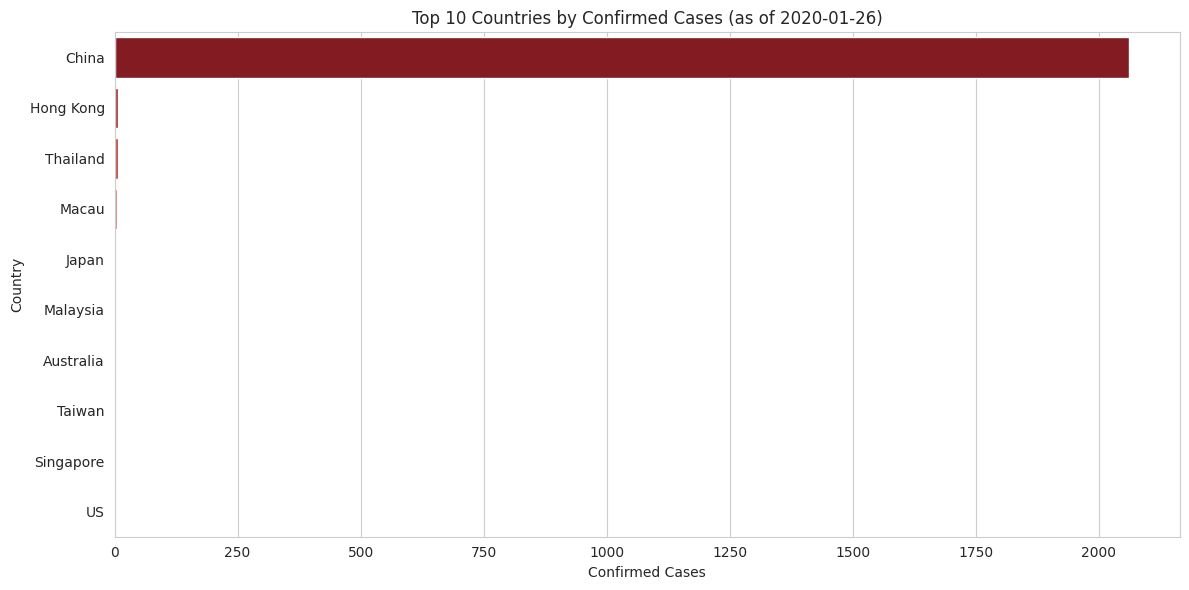

In [10]:
top_countries = country_totals.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries['Confirmed'], y=top_countries.index, palette='Reds_r')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.title(f'Top 10 Countries by Confirmed Cases (as of {latest_date})')
plt.tight_layout()
plt.show()

## 7. Recovered vs Deaths by Country

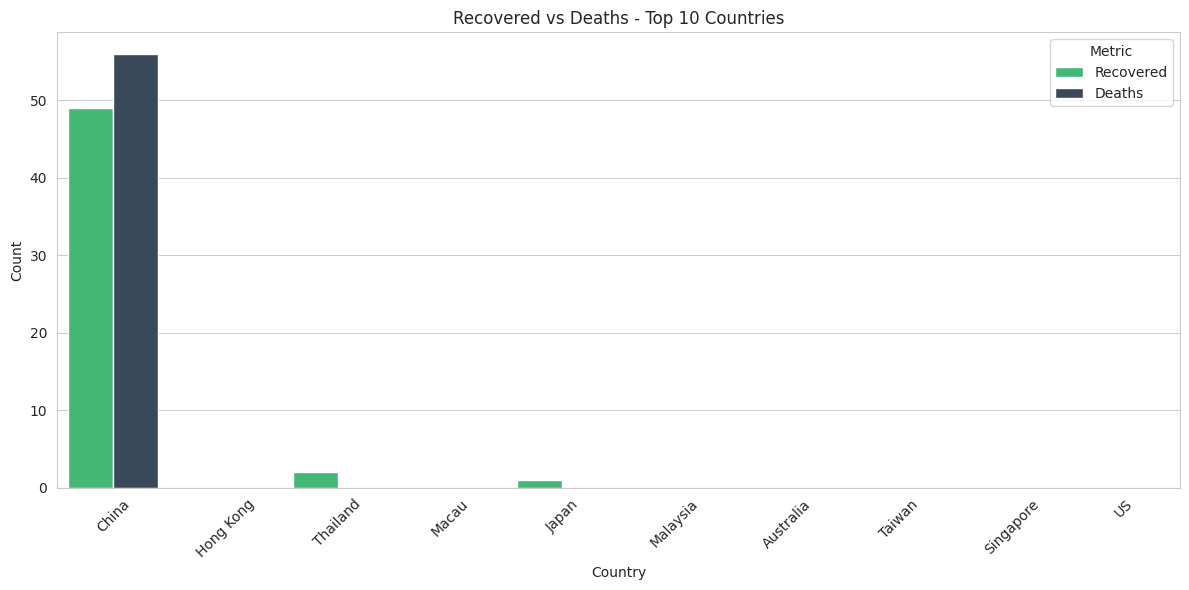

In [11]:
top10_melt = top_countries.reset_index().melt(id_vars='Country', value_vars=['Recovered', 'Deaths'], var_name='Metric', value_name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_melt, x='Country', y='Count', hue='Metric', palette=['#2ecc71', '#34495e'])
plt.xticks(rotation=45)
plt.title('Recovered vs Deaths - Top 10 Countries')
plt.tight_layout()
plt.show()

## 8. Province/State Breakdown (China)

/tmp/ipykernel_619/2246717891.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=china_provinces.values, y=china_provinces.index, palette='OrRd_r')


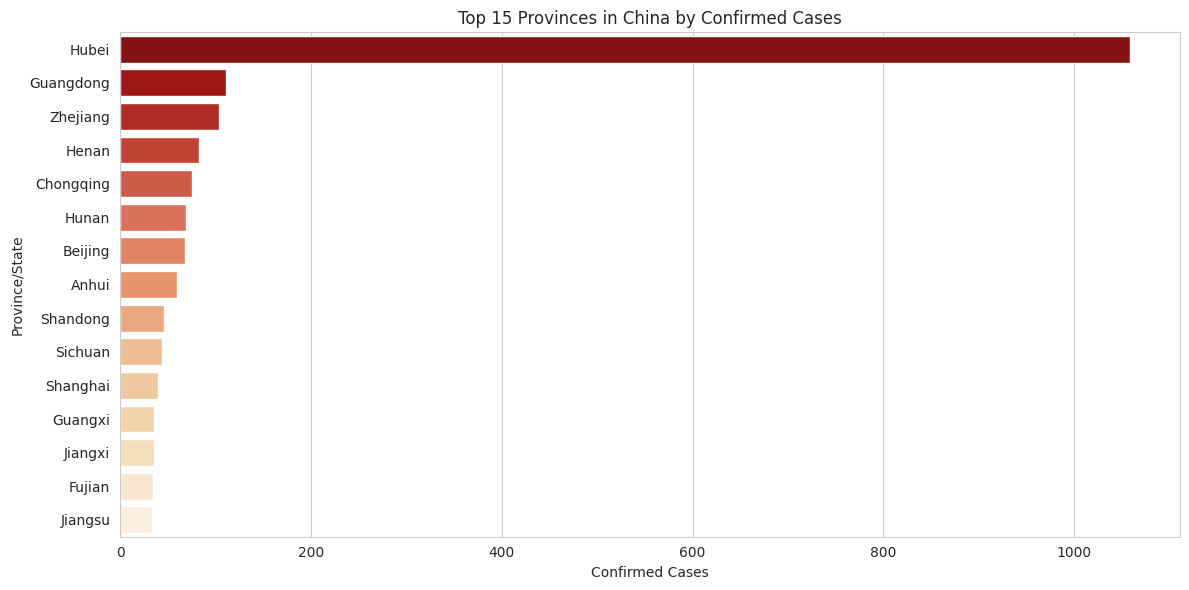

In [12]:
china_df = latest_df[latest_df['Country'] == 'China']
china_provinces = china_df.groupby('Province/State')['Confirmed'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=china_provinces.values, y=china_provinces.index, palette='OrRd_r')
plt.xlabel('Confirmed Cases')
plt.ylabel('Province/State')
plt.title('Top 15 Provinces in China by Confirmed Cases')
plt.tight_layout()
plt.show()

## 9. Interactive Visualization with Plotly

In [13]:
fig = px.line(trend, x='Date', y=['Confirmed', 'Recovered', 'Deaths'],
              title='Interactive Global COVID-19 Trends',
              labels={'value': 'Count', 'variable': 'Metric'},
              markers=True)
fig.update_layout(hovermode='x unified')
fig.show()

In [14]:
fig = px.bar(top_countries.reset_index(), x='Country', y='Confirmed',
             title=f'Confirmed Cases by Country (as of {latest_date})',
             color='Confirmed', color_continuous_scale='Reds')
fig.show()

In [15]:
daily_country = df.groupby(['Date', 'Country'])['Confirmed'].sum().reset_index()

fig = px.scatter(daily_country, x='Date', y='Confirmed', color='Country', size='Confirmed',
                  title='Confirmed Cases by Country Over Time', size_max=40)
fig.show()

## 10. Case Fatality and Recovery Rates

In [16]:
global_totals = latest_df[['Confirmed', 'Recovered', 'Deaths']].sum()
fatality_rate = (global_totals['Deaths'] / global_totals['Confirmed']) * 100
recovery_rate = (global_totals['Recovered'] / global_totals['Confirmed']) * 100

print(f"Case Fatality Rate: {fatality_rate:.2f}%")
print(f"Recovery Rate: {recovery_rate:.2f}%")

Case Fatality Rate: 2.65%
Recovery Rate: 2.46%


In [17]:
fig = go.Figure(data=[go.Pie(labels=['Recovered', 'Deaths', 'Active/Other'],
                              values=[global_totals['Recovered'], global_totals['Deaths'],
                                      global_totals['Confirmed'] - global_totals['Recovered'] - global_totals['Deaths']],
                              hole=0.4,
                              marker_colors=['#2ecc71', '#34495e', '#e67e22'])])
fig.update_layout(title='Global Case Outcome Distribution')
fig.show()